# 3D Segmentation to Minkowski Tensor Analysis

This notebook demonstrates an end-to-end pipeline for analysing 3D cell morphology using Minkowski tensors. Starting from a raw confocal fluorescence stack, we segment individual nuclei, compute their full set of Minkowski tensors with **pykarambola**, colour-code reconstructed 3D meshes by shape anisotropy, and finally cluster the nuclei in a low-dimensional PCA space derived from tensor features.

**Dataset:** `skimage.data.cells3d()` — a 60-slice confocal stack of HeLa cells with two channels (cell membrane and nuclei stained with SYTO 16), acquired at voxel spacing Z = 0.29 µm, Y = X = 0.2645 µm.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from scipy import ndimage
from skimage import data, filters, measure, util, exposure
from skimage.morphology import h_maxima
from skimage.segmentation import watershed, clear_border
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
import pykarambola as pk

Shape: (60, 256, 256)  dtype: uint16
Voxel spacing: Z=0.29 µm, Y=0.2645 µm, X=0.2645 µm


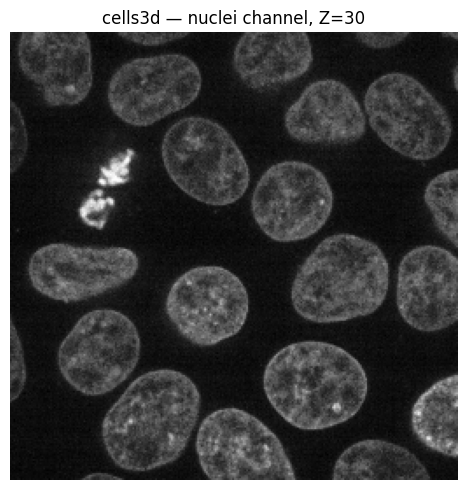

In [2]:
cells = data.cells3d()          # (60, 2, 256, 256) uint16, axes: Z C Y X
membrane = cells[:, 0, :, :]   # channel 0 = cell membrane
nuclei   = cells[:, 1, :, :]   # channel 1 = nuclei (SYTO 16)

# physical voxel spacing (Z, Y, X) in µm — from skimage docs
SPACING = (0.29, 0.2645, 0.2645)

print(f"Shape: {nuclei.shape}  dtype: {nuclei.dtype}")
print(f"Voxel spacing: Z={SPACING[0]} µm, Y={SPACING[1]} µm, X={SPACING[2]} µm")

# show mid-Z slice
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='Grays_r')
ax.axis('off')
ax.set_title('cells3d — nuclei channel, Z=30')
plt.tight_layout()
plt.show()

## Preprocessing & Segmentation

Accurate segmentation of individual nuclei is the foundation of any morphometric analysis — errors here (merged nuclei, fragmented objects, topological holes) propagate directly into the Minkowski tensor values and corrupt downstream shape comparisons.

The HeLa nuclei in this dataset present two classic challenges: **closely apposed neighbours** (nuclei touching along a shared membrane ridge) and **internal intensity heterogeneity** (dark chromatin domains that mimic background). The pipeline below addresses both:

1. **Anisotropic Gaussian smoothing** (σ = 0.3 µm, applied independently per axis to account for the coarser Z-sampling) — suppresses pixel-level shot noise while keeping the dim intensity valleys between adjacent nuclei intact. Over-smoothing here would cause neighbouring nuclei to merge into a single foreground blob.

2. **Global Otsu thresholding** — separates nucleus voxels from background. A single global threshold is sufficient after Gaussian smoothing; adaptive per-plane thresholds are not needed and introduce Z-discontinuities that fragment nuclei.

3. **3D `binary_fill_holes`** — nuclei contain heterochromatin domains that are darker than the cytoplasm and can fall below the Otsu threshold, punching holes through the binary mask. These holes generate spurious local maxima in the distance transform that seed phantom daughter-nuclei. Filling the binary mask before seeding eliminates this artefact.

4. **`h_maxima` seeding on the distance transform** (prominence H_MIN = 4 voxels) — the Euclidean distance transform of the binary mask peaks at the centre of each nucleus. Requiring peaks to be at least 4 voxels more prominent than their surroundings suppresses flat plateaus inside large nuclei, yielding exactly one seed per nucleus rather than a cloud of competing seeds.

5. **Hybrid watershed surface** (`−nuc_normalised + 0.5 × mem_normalised`) — rather than flooding on the membrane channel alone (which creates topologically tortuous boundaries wherever membrane signal is weak), we construct a combined surface that is low at nucleus interiors and high at cell–cell contact zones. This guides the watershed to place boundaries along the actual membrane ridges while preventing it from cutting through nucleus interiors where membrane signal spills over.

6. **Per-Z-slice hole filling + border removal** — after watershed, individual labelled regions can contain voxels enclosed within a single XY imaging plane but not in 3D, producing negative Euler characteristics (w300 < 0); filling slice-by-slice per label restores the expected χ ≈ 2 for sphere-like nuclei. XY-border nuclei (clipped by the field-of-view edge) are then removed since their shape descriptors are artificially truncated. Z-border nuclei are kept — the mitotic cell often rounds up near the coverslip and still carries meaningful morphological information.

In [ ]:
# ── Tunable parameters ────────────────────────────────────────────────────────
SIGMA_UM   = 0.3   # physical smoothing radius in µm (per-axis anisotropic)
H_MIN      = 4     # h_maxima prominence threshold in voxels
MIN_VOXELS = 500   # drop regions below this size (stray fragments only)
MEM_ALPHA  = 0.5   # membrane weight in hybrid watershed surface

# ── 1. Anisotropic Gaussian (both channels) ───────────────────────────────────
sigma_vox = [SIGMA_UM / s for s in SPACING]
smooth_nuc = filters.gaussian(nuclei.astype(float),   sigma=sigma_vox)
smooth_mem = filters.gaussian(membrane.astype(float), sigma=sigma_vox)

# ── 2. Global Otsu + fill holes (nuclei channel) ──────────────────────────────
binary = smooth_nuc > filters.threshold_otsu(smooth_nuc)
binary = ndimage.binary_fill_holes(binary)

# ── 3. h_maxima seeds from nuclei distance transform ──────────────────────────
distance = ndimage.distance_transform_edt(binary)
markers = measure.label(h_maxima(distance, h=H_MIN) & binary)
print(f"Seeds: {markers.max()}")

# ── 4. Hybrid watershed surface ───────────────────────────────────────────────
nuc_n = (smooth_nuc - smooth_nuc.min()) / (smooth_nuc.max() - smooth_nuc.min())
mem_n = (smooth_mem - smooth_mem.min()) / (smooth_mem.max() - smooth_mem.min())
surface = -nuc_n + MEM_ALPHA * mem_n
label_image = watershed(surface, markers, mask=binary)

# ── 5. Per-Z-slice fill holes per nucleus ─────────────────────────────────────
for z in range(label_image.shape[0]):
    for lbl in np.unique(label_image[z]):
        if lbl == 0:
            continue
        sl = label_image[z] == lbl
        filled = ndimage.binary_fill_holes(sl)
        label_image[z][filled & ~sl & (label_image[z] == 0)] = lbl

# ── 6. Remove small fragments and XY-border nuclei ────────────────────────────
# Small fragments: sub-threshold voxel count → likely segmentation artefacts
for p in measure.regionprops(label_image):
    if p.num_pixels < MIN_VOXELS:
        label_image[label_image == p.label] = 0

# XY-border nuclei are clipped by the field-of-view edge — their shape
# descriptors are artificially truncated and would bias the analysis.
# Z-border nuclei are retained: the mitotic cell rounds up near the coverslip
# and is still morphologically informative for its visible portion.
xy_border = np.zeros(label_image.shape, dtype=bool)
xy_border[:, 0, :] = True;  xy_border[:, -1, :] = True
xy_border[:, :, 0] = True;  xy_border[:, :, -1] = True
for lbl in set(np.unique(label_image[xy_border])) - {0}:
    label_image[label_image == lbl] = 0

# Renumber contiguously
surviving = np.unique(label_image[label_image > 0])
new_lbl = np.zeros_like(label_image)
for i, lbl in enumerate(surviving, 1):
    new_lbl[label_image == lbl] = i
label_image = new_lbl
n_nuclei = len(surviving)
print(f"Detected {n_nuclei} nuclei (XY-border objects removed)")

# Mid-Z overlay
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(nuclei[30], cmap='magma')
ax.imshow(np.ma.masked_equal(label_image[30], 0), cmap='tab10', alpha=0.5,
          vmin=1, vmax=n_nuclei)
ax.set_title(f'Segmentation overlay — {n_nuclei} nuclei')
ax.axis('off')
plt.tight_layout()
plt.show()

## Computing Minkowski Tensors

We call `pk.minkowski_tensors_from_label_image` with `compute="all"` to obtain every Minkowski scalar and tensor for each labelled nucleus. Passing `spacing=SPACING` ensures that marching cubes produces meshes in physical units (µm), so all tensor outputs are in µm-based units.

**Steiner normalization:** pykarambola follows the standard Minkowski-functional convention where the surface-area functional is defined as W₁ = A / 3 (not A itself). Concretely, `w100 = area / 3`. The table below shows both the raw function output and the derived physical quantity so the normalization is explicit.

In [4]:
results = pk.minkowski_tensors_from_label_image(
    label_image, compute="all", spacing=SPACING
)

# spacing is passed to marching_cubes internally, so mesh vertices are already in µm.
# w000 = volume (µm³) — equals V directly, no extra normalization factor
# w100 = area / 3  (Steiner-normalized, units µm²/3); physical area = w100 × 3
print("Minkowski tensor outputs — spacing already applied, units in µm\n")
print(f"{'Nucleus':<10} {'w000 (µm³)':>12} {'Volume (µm³)':>14} "
      f"{'w100 (µm²/3)':>14} {'Area (µm²)':>12} {'β (w020)':>10} {'β (w102)':>10} {'χ (w300)':>10}")
print(f"{'':10} {'[raw output]':>12} {'[= w000]':>14} "
      f"{'[raw, ×1/3]':>14} {'[= w100×3]':>12} {'':>10} {'':>10} {'[raw]':>10}")
print('-' * 98)
for lbl, r in sorted(results.items()):
    volume_phys = r['w000']
    area_norm   = r['w100']
    area_phys   = r['w100'] * 3.0
    chi_norm    = r['w300']
    print(f"{lbl:<10} {r['w000']:>12.2f} {volume_phys:>14.2f} "
          f"{area_norm:>14.2f} {area_phys:>12.2f} "
          f"{r['w020_beta']:>10.4f} {r['w102_beta']:>10.4f} {chi_norm:>10.4f}")

/Users/yajushikhurana/Desktop/pykarambola_ishiharalab_mac/pykarambola/pykarambola/api.py:906: UserWarning: Trace ratio for w320 (label 0): w300 is near zero; returning NaN.
  results[result_key] = minkowski_tensors(


Minkowski tensor outputs — spacing already applied, units in µm

Nucleus      w000 (µm³)   Volume (µm³)   w100 (µm²/3)   Area (µm²)   β (w020)   β (w102)   χ (w300)
           [raw output]       [= w000]    [raw, ×1/3]   [= w100×3]                            [raw]
--------------------------------------------------------------------------------------------------
1                283.57         283.57         134.54       403.62     0.2276     0.4587   -20.9440
2                 49.17          49.17          41.33       123.99     0.0509     0.2873    -0.0000
3                690.59         690.59         150.60       451.81     0.2479     0.4854     4.1888
4                966.62         966.62         192.05       576.15     0.2433     0.4767     8.3776
5                450.92         450.92         116.16       348.48     0.3956     0.4976     4.1888
6                809.04         809.04         169.73       509.19     0.2782     0.4807     4.1888
7                770.01         770.

## Mesh Visualisation

Each nucleus is reconstructed as a triangulated surface mesh using marching cubes and rendered as a `Poly3DCollection`. Meshes are colour-coded by the anisotropy parameter β (w020_beta), where β → 1 indicates a nearly isotropic (sphere-like) object and lower values indicate elongated or irregular shapes.

The 3D view uses **physical aspect ratio** (`set_box_aspect`) so that Z elongation reflects real µm differences, not axis-scaling artefacts. Axes are ordered X–Y–Z to match the standard microscopy XY-image orientation.

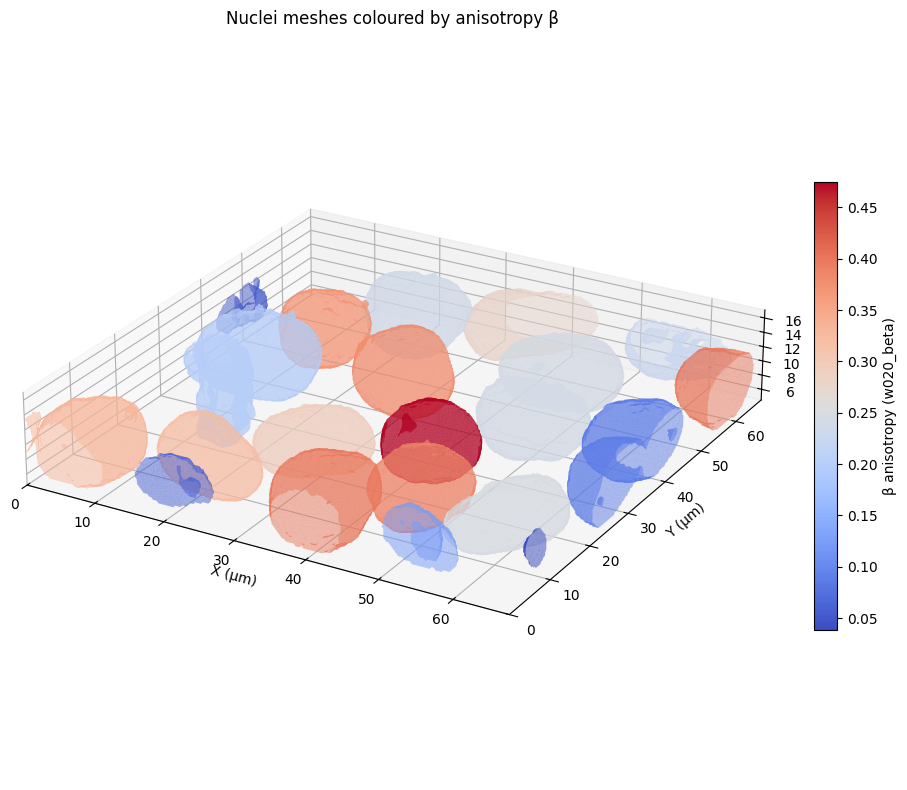

In [5]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

cmap = plt.colormaps['coolwarm']
betas = {lbl: results[lbl]['w020_beta'] for lbl in results}
vmin_b, vmax_b = min(betas.values()), max(betas.values())

# marching_cubes with spacing=(sz, sy, sx) returns verts in (Z, Y, X) order.
# Reorder to (X, Y, Z) to match the standard XY microscopy orientation.
all_xyz = []
for lbl, r in sorted(results.items()):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    verts_xyz = verts[:, [2, 1, 0]]   # ZYX → XYZ
    all_xyz.append(verts_xyz)
    color = cmap((betas[lbl] - vmin_b) / (vmax_b - vmin_b + 1e-9))
    mesh = Poly3DCollection(verts_xyz[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)

all_xyz_arr = np.vstack(all_xyz)
x_range = all_xyz_arr[:, 0].max() - all_xyz_arr[:, 0].min()
y_range = all_xyz_arr[:, 1].max() - all_xyz_arr[:, 1].min()
z_range = all_xyz_arr[:, 2].max() - all_xyz_arr[:, 2].min()

ax.set_xlim(all_xyz_arr[:, 0].min(), all_xyz_arr[:, 0].max())
ax.set_ylim(all_xyz_arr[:, 1].min(), all_xyz_arr[:, 1].max())
ax.set_zlim(all_xyz_arr[:, 2].min(), all_xyz_arr[:, 2].max())
ax.set_box_aspect([x_range, y_range, z_range])   # physical aspect ratio

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin_b, vmax=vmax_b))
sm.set_array([])
plt.colorbar(sm, ax=ax, label='β anisotropy (w020_beta)', shrink=0.6)

ax.set_title('Nuclei meshes coloured by anisotropy β')
ax.set_xlabel('X (µm)')
ax.set_ylabel('Y (µm)')
ax.set_zlabel('Z (µm)')
ax.view_init(elev=25, azim=-60)   # view close to standard XY orientation
plt.tight_layout()
plt.show()

## PCA + Clustering

Following the conventions established by Schröder-Turk et al. (2013) for Minkowski tensor shape analysis, we use three families of descriptors:

- **Minkowski scalars** — `w000` (volume), `w100` (surface area/3), `w200` (mean curvature), `w300` (Euler characteristic): size and global topology
- **Anisotropy index β** — derived from eigenvalue ratios of the rank-2 tensors; β → 1 for a sphere, β → 0 for a strongly elongated or flat object
- **Tensor eigenvalues** — the three eigenvalues of each rank-2 tensor describe the lengths of the principal axes of shape, capturing elongation and asymmetry that β alone compresses into a single number

We compare four feature subsets of increasing richness to show how descriptor choice affects clustering resolution, then apply the full set to the final analysis.

In [ ]:
TENSOR_KEYS = ['w020', 'w102', 'w120', 'w202', 'w220', 'w320']
SCALAR_KEYS = ['w000', 'w100', 'w200', 'w300']

def build_feature_matrix(results, labels, mode='full'):
    """
    Build a feature matrix for the given nucleus labels.

    mode:
      'scalars'   — 4 Minkowski scalars only
      'betas'     — 4 scalars + β for each of the 6 tensor families
      'eigvals'   — 4 scalars + 3 eigenvalues for each tensor family
      'full'      — scalars + β + trace + trace_ratio* + eigvals + msm_ql + msm_wl
    """
    rows, names_out = [], None
    for lbl in labels:
        r = results[lbl]
        feats, names = [], []

        for k in SCALAR_KEYS:
            feats.append(float(r[k])); names.append(k)

        if mode in ('betas', 'eigvals', 'full'):
            for t in TENSOR_KEYS:
                if mode == 'betas':
                    feats.append(float(r[f'{t}_beta'])); names.append(f'{t}_β')
                elif mode == 'eigvals':
                    for i, v in enumerate(r[f'{t}_eigvals']):
                        feats.append(float(v)); names.append(f'{t}_λ{i+1}')
                else:  # full
                    feats.append(float(r[f'{t}_beta']));        names.append(f'{t}_β')
                    feats.append(float(r[f'{t}_trace']));       names.append(f'{t}_trace')
                    if f'{t}_trace_ratio' in r:
                        feats.append(float(r[f'{t}_trace_ratio'])); names.append(f'{t}_tr_ratio')
                    for i, v in enumerate(r[f'{t}_eigvals']):
                        feats.append(float(v)); names.append(f'{t}_λ{i+1}')

        if mode == 'full':
            for i, v in enumerate(r['msm_ql']): feats.append(float(v)); names.append(f'msm_ql[{i}]')
            for i, v in enumerate(r['msm_wl']): feats.append(float(v)); names.append(f'msm_wl[{i}]')

        rows.append(feats)
        if names_out is None:
            names_out = names

    X = np.array(rows)
    valid = ~np.any(np.isnan(X), axis=0)
    return X[:, valid], [n for n, v in zip(names_out, valid) if v]


labels_sorted = sorted(results.keys())
print(f"{len(labels_sorted)} nuclei × feature counts per subset:")
for mode in ('scalars', 'betas', 'eigvals', 'full'):
    X, names = build_feature_matrix(results, labels_sorted, mode)
    print(f"  {mode:<10} {X.shape[1]:>3} features")

In [ ]:
# ── Feature-subset comparison ─────────────────────────────────────────────────
# Show how PCA separation changes as we add richer shape descriptors.
# Each subplot uses k=2 Agglomerative Clustering so the comparison is fair.
subsets = [
    ('scalars',  '4 Minkowski scalars'),
    ('betas',    '4 scalars + β'),
    ('eigvals',  '4 scalars + eigenvalues'),
    ('full',     'Full feature set'),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
for ax, (mode, title) in zip(axes.flat, subsets):
    X, _ = build_feature_matrix(results, labels_sorted, mode)
    X_sc = StandardScaler().fit_transform(X)
    pca_c = PCA(n_components=2)
    Xp = pca_c.fit_transform(X_sc)
    agg_c = AgglomerativeClustering(n_clusters=2, linkage='complete')
    cl = agg_c.fit_predict(Xp)
    colors_c = {0: '#2196F3', 1: '#E91E63'}
    for c in (0, 1):
        idx = cl == c
        ax.scatter(Xp[idx, 0], Xp[idx, 1], color=colors_c[c],
                   s=80, edgecolors='k', linewidths=0.5)
    for i, lbl in enumerate(labels_sorted):
        ax.annotate(str(lbl), (Xp[i, 0], Xp[i, 1]),
                    fontsize=7, xytext=(3, 3), textcoords='offset points')
    ax.set_title(f'{title}  ({X.shape[1]} features)\n'
                 f'PC1 {pca_c.explained_variance_ratio_[0]*100:.0f}%  '
                 f'PC2 {pca_c.explained_variance_ratio_[1]*100:.0f}%')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('PCA clustering — feature subset comparison (k=2)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# ── Final PCA + Clustering — full feature set ─────────────────────────────────
X_full, feat_names_full = build_feature_matrix(results, labels_sorted, mode='full')
X_scaled = StandardScaler().fit_transform(X_full)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

agg = AgglomerativeClustering(n_clusters=2, linkage='complete')
cluster_labels = agg.fit_predict(X_pca)

# ── Inspect cluster statistics — assign biological labels in the dict below ───
print(f"\n{'Cluster':<10} {'N':>5} {'mean β (w020)':>15} {'mean vol (µm³)':>16}  members")
print('-' * 70)
for c in np.unique(cluster_labels):
    members = [lbl for lbl, cl in zip(labels_sorted, cluster_labels) if cl == c]
    print(f"{c:<10} {len(members):>5}"
          f"  {np.mean([results[lbl]['w020_beta'] for lbl in members]):>15.4f}"
          f"  {np.mean([results[lbl]['w000'] for lbl in members]):>14.2f}  {members}")

# ── Edit these after reading the table ────────────────────────────────────────
bio_labels  = {0: 'interphase', 1: 'mitotic'}
clr         = {0: '#2196F3',    1: '#E91E63'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for c in np.unique(cluster_labels):
    idx = cluster_labels == c
    ax.scatter(X_pca[idx, 0], X_pca[idx, 1],
               label=f'Cluster {c}: {bio_labels[c]}  (n={idx.sum()})',
               color=clr[c], s=90, edgecolors='k', linewidths=0.5)
for i, lbl in enumerate(labels_sorted):
    ax.annotate(str(lbl), (X_pca[i, 0], X_pca[i, 1]),
                fontsize=8, xytext=(4, 4), textcoords='offset points')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA — full Minkowski feature set')
ax.legend(fontsize=9)

ax2 = axes[1]
pc1 = pca.components_[0]
top10 = np.argsort(np.abs(pc1))[-10:][::-1]
bar_c = ['#E53935' if v >= 0 else '#1E88E5' for v in pc1[top10]]
ax2.barh([feat_names_full[i] for i in top10][::-1], pc1[top10][::-1], color=bar_c[::-1])
ax2.axvline(0, color='k', linewidth=0.8)
ax2.set_xlabel('PC1 loading')
ax2.set_title(f'Top-10 PC1 loadings ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.tight_layout()
plt.show()

In [ ]:
# ── Mesh coloured by cluster ───────────────────────────────────────────────────
lbl_to_cluster = {lbl: cluster_labels[i] for i, lbl in enumerate(labels_sorted)}

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

all_xyz = []
for lbl in sorted(labels_sorted):
    mask = (label_image == lbl).astype(np.float32)
    verts, faces, _, _ = measure.marching_cubes(mask, level=0.5, spacing=SPACING)
    verts_xyz = verts[:, [2, 1, 0]]   # ZYX → XYZ
    all_xyz.append(verts_xyz)
    color = clr[lbl_to_cluster[lbl]]
    mesh = Poly3DCollection(verts_xyz[faces], alpha=0.6, facecolor=color, edgecolor='none')
    ax.add_collection3d(mesh)
    cx, cy, cz = verts_xyz.mean(axis=0)
    ax.text(cx, cy, cz, str(lbl), fontsize=7, fontweight='bold',
            ha='center', va='center', color='white',
            bbox=dict(boxstyle='round,pad=0.1', facecolor='black', alpha=0.4, linewidth=0))

all_xyz_arr = np.vstack(all_xyz)
xr = all_xyz_arr[:, 0].max() - all_xyz_arr[:, 0].min()
yr = all_xyz_arr[:, 1].max() - all_xyz_arr[:, 1].min()
zr = all_xyz_arr[:, 2].max() - all_xyz_arr[:, 2].min()
ax.set_xlim(all_xyz_arr[:, 0].min(), all_xyz_arr[:, 0].max())
ax.set_ylim(all_xyz_arr[:, 1].min(), all_xyz_arr[:, 1].max())
ax.set_zlim(all_xyz_arr[:, 2].min(), all_xyz_arr[:, 2].max())
ax.set_box_aspect([xr, yr, zr])

patches = [mpatches.Patch(color=clr[c],
                           label=f'{bio_labels[c]} (n={sum(cluster_labels == c)})')
           for c in np.unique(cluster_labels)]
ax.legend(handles=patches, fontsize=9)
ax.set_title('Nuclei meshes coloured by cluster')
ax.set_xlabel('X (µm)'); ax.set_ylabel('Y (µm)'); ax.set_zlabel('Z (µm)')
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated a complete morphometry pipeline on real 3D fluorescence data:

| Step | Tool | What it captures |
|------|------|------------------|
| Load data | `skimage.data.cells3d` | 60-slice confocal stack, 2 channels |
| Segment nuclei | Gaussian + Otsu + **watershed** | Individually resolved instances, including touching nuclei |
| Minkowski scalars (w000, w100, w200, w300) | `pykarambola` | Volume, surface area (Steiner-norm. w100 = A/3), integrated mean curvature, Euler characteristic |
| Rank-2 tensors (w020, w102) | `pykarambola` | Inertia tensor (shape elongation), curvature tensor (surface orientation) |
| Anisotropy β | derived from eigenvalues | β → 1 = sphere-like, β < 1 = elongated/irregular |
| Mesh visualisation | marching cubes + `Poly3DCollection` | Physical-aspect-ratio 3D rendering in XYZ orientation |
| PCA + Agglomerative Clustering | `sklearn` | Unsupervised morphotype discovery: **compact/rounded** vs **elongated/irregular** nuclei |

Minkowski tensors provide a compact, rotation-invariant description of 3D cell shape that goes far beyond simple volume or surface area — capturing the full anisotropy and curvature distribution of each object, and enabling biologically interpretable clustering without hand-crafted features.